In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/model1_dataset.csv")
df.drop(columns=["Time", "Unnamed: 0"], inplace=True)
df.shape

(87908, 53)

In [3]:
df.isnull().sum()

Driver                          0
Position                        0
Team                            0
Compound                        0
TyreLife                      631
LapTime                       116
mean_last_5                     0
median_last_5                   0
mean_last_3                     0
median_last_3                   0
p_minus1_time_delta          2735
p_minus2_time_delta          2529
p_minus3_time_delta          2296
p_plus1_time_delta           2925
p_plus2_time_delta           2627
p_plus3_time_delta           1031
p_minus1_mean_LapTime        2735
p_minus2_mean_LapTime        2529
p_minus3_mean_LapTime        2296
p_minus1_median_LapTime      2735
p_minus2_median_LapTime      2529
p_minus3_median_LapTime      2296
p_plus1_mean_LapTime         2925
p_plus2_mean_LapTime         2627
p_plus3_mean_LapTime         1031
p_plus1_median_LapTime       2925
p_plus2_median_LapTime       2627
p_plus3_median_LapTime       1031
p_3_minus1_mean_LapTime      2746
p_3_minus2_mea

In [4]:
df.describe()

,Position,TyreLife,LapTime,mean_last_5,median_last_5,mean_last_3,median_last_3,p_minus1_time_delta,p_minus2_time_delta,p_minus3_time_delta,...,p_plus1_LapTime,p_plus2_LapTime,p_plus3_LapTime,target,p_minus1_exists,p_minus2_exists,p_minus3_exists,p_plus1_exists,p_plus2_exists,p_plus3_exists
count,87908.000000,87277.000000,87792.000000,87908.000000,87908.000000,87908.000000,87908.000000,85173.000000,85379.000000,85612.000000,...,84983.000000,85281.000000,86877.000000,87908.000000,87908.000000,87908.000000,87908.000000,87908.000000,87908.000000,87908.000000
mean,9.471356,16.262360,88.410175,89.022193,88.628915,88.693291,88.523415,64.067339,125.589165,186.039264,...,92.917778,97.634791,103.712481,0.109160,0.942201,0.885767,0.829231,0.989182,0.966101,0.966101
std,5.290717,8.953957,12.251904,12.271318,12.377192,12.258731,12.375292,235.675117,319.150269,375.168282,...,23.503724,30.443292,36.668317,1.820967,0.233364,0.318096,0.376310,0.103447,0.180970,0.180970
min,1.000000,0.000000,56.393000,56.524400,56.514000,56.515000,56.442000,-69.463000,-68.048000,-67.323000,...,55.404000,55.404000,55.404000,-16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,9.000000,80.098000,80.644700,80.212750,80.385000,80.151000,1.166000,3.079000,5.371000,...,80.592500,81.130000,81.780000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,9.000000,14.000000,86.061000,86.958100,86.190000,86.334833,86.063500,2.500000,6.458000,11.277500,...,87.291000,89.149000,91.440000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,14.000000,21.000000,96.771000,97.668050,97.092000,97.199667,96.920000,6.241000,15.739000,29.062000,...,98.273500,99.961000,103.606000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,20.000000,73.000000,149.966000,145.038250,147.449000,147.717500,149.529000,999.000000,999.000000,999.000000,...,280.436000,280.436000,284.954000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87908 entries, 0 to 87907
Data columns (total 53 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Driver                     87908 non-null  object 
 1   Position                   87908 non-null  int64  
 2   Team                       87908 non-null  object 
 3   Compound                   87908 non-null  object 
 4   TyreLife                   87277 non-null  float64
 5   LapTime                    87792 non-null  float64
 6   mean_last_5                87908 non-null  float64
 7   median_last_5              87908 non-null  float64
 8   mean_last_3                87908 non-null  float64
 9   median_last_3              87908 non-null  float64
 10  p_minus1_time_delta        85173 non-null  float64
 11  p_minus2_time_delta        85379 non-null  float64
 12  p_minus3_time_delta        85612 non-null  float64
 13  p_plus1_time_delta         84983 non-null  flo

In [6]:
df

,Driver,Position,Team,Compound,TyreLife,LapTime,mean_last_5,median_last_5,mean_last_3,median_last_3,...,p_plus1_LapTime,p_plus2_LapTime,p_plus3_LapTime,target,p_minus1_exists,p_minus2_exists,p_minus3_exists,p_plus1_exists,p_plus2_exists,p_plus3_exists
0,VER,1,Red Bull Racing,MEDIUM,5.0,93.955,94.2924,94.043,93.917333,93.955,...,94.085,94.382,94.557,-1,0,0,0,1,1,1
1,PER,2,Red Bull Racing,MEDIUM,5.0,94.085,94.7846,94.085,94.062000,94.055,...,94.382,94.557,94.512,-2,1,0,0,1,1,1
2,ALO,5,Aston Martin,MEDIUM,6.0,94.512,95.5856,94.746,94.565667,94.512,...,94.902,95.150,95.107,-2,1,1,1,1,1,1
3,LEC,3,Ferrari,MEDIUM,5.0,94.382,95.0008,94.549,94.714667,94.549,...,94.557,94.512,94.902,-2,1,1,0,1,1,1
4,SAR,18,Williams,MEDIUM,5.0,96.204,98.6994,96.871,96.539667,96.544,...,96.238,193.742,193.742,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87903,SAI,4,McLaren,MEDIUM,27.0,57.648,57.4252,57.531,57.348333,57.232,...,57.492,57.339,57.448,0,1,1,1,1,1,1
87904,RAI,14,Alfa Romeo Racing,SOFT,20.0,57.870,57.9630,57.811,58.071667,57.870,...,58.202,58.012,59.696,0,1,1,1,1,1,1
87905,BOT,8,Mercedes,HARD,33.0,57.198,57.7038,57.546,57.260667,57.198,...,57.590,57.356,57.670,0,1,1,1,1,1,1
87906,AIT,16,Williams,SOFT,23.0,58.012,58.2066,58.193,58.141667,58.018,...,59.696,116.386,116.386,0,1,1,1,1,1,1


In [7]:
df["Team"].value_counts()

Team
McLaren              9303
Mercedes             9251
Red Bull Racing      8960
Ferrari              8818
Racing Bulls         8638
Haas F1 Team         8523
Williams             8170
Aston Martin         7645
Alpine               7619
Kick Sauber          3269
Alfa Romeo           2751
Alfa Romeo Racing    2719
Renault              1144
Racing Point         1098
Name: count, dtype: int64

In [8]:
df.corr(numeric_only=True)

,Position,TyreLife,LapTime,mean_last_5,median_last_5,mean_last_3,median_last_3,p_minus1_time_delta,p_minus2_time_delta,p_minus3_time_delta,...,p_plus1_LapTime,p_plus2_LapTime,p_plus3_LapTime,target,p_minus1_exists,p_minus2_exists,p_minus3_exists,p_plus1_exists,p_plus2_exists,p_plus3_exists
Position,1.000000,-0.114167,0.042808,0.038824,0.037508,0.039394,0.037899,-0.399742,-0.545544,-0.646230,...,0.325572,0.459755,0.531583,0.196348,0.396579,0.541479,0.641482,-0.208113,-0.348665,-0.348665
TyreLife,-0.114167,1.000000,-0.145024,-0.180791,-0.167666,-0.160689,-0.156223,0.030494,0.035218,0.034630,...,-0.151501,-0.154207,-0.154649,-0.178687,-0.027175,-0.029768,-0.028226,0.055486,0.098347,0.098347
LapTime,0.042808,-0.145024,1.000000,0.929910,0.915751,0.964470,0.953447,-0.027261,-0.034383,-0.040410,...,0.551662,0.449470,0.397040,-0.013085,0.025901,0.032559,0.038108,0.000669,-0.012138,-0.012138
mean_last_5,0.038824,-0.180791,0.929910,1.000000,0.983137,0.979450,0.964895,-0.029221,-0.037060,-0.043262,...,0.519406,0.426496,0.379007,-0.012101,0.026545,0.033347,0.038754,0.004843,-0.006017,-0.006017
median_last_5,0.037508,-0.167666,0.915751,0.983137,1.000000,0.977625,0.964531,-0.027960,-0.035170,-0.041441,...,0.511099,0.419445,0.373718,-0.011880,0.025484,0.031720,0.037280,0.003699,-0.006953,-0.006953
mean_last_3,0.039394,-0.160689,0.964470,0.979450,0.977625,1.000000,0.990548,-0.028101,-0.035530,-0.041666,...,0.536997,0.439635,0.390087,-0.013922,0.026105,0.032771,0.038289,0.003210,-0.008148,-0.008148
median_last_3,0.037899,-0.156223,0.953447,0.964895,0.964531,0.990548,1.000000,-0.027131,-0.034165,-0.040207,...,0.529900,0.433117,0.384415,-0.013559,0.025152,0.031442,0.036881,0.002952,-0.008029,-0.008029
p_minus1_time_delta,-0.399742,0.030494,-0.027261,-0.029221,-0.027960,-0.028101,-0.027131,1.000000,0.691853,0.549244,...,-0.054092,-0.076323,-0.102738,-0.053640,-0.999193,-0.691814,-0.549544,0.021611,0.040649,0.040649
p_minus2_time_delta,-0.545544,0.035218,-0.034383,-0.037060,-0.035170,-0.035530,-0.034165,0.691853,1.000000,0.793233,...,-0.076849,-0.111432,-0.149380,-0.074896,-0.688412,-0.999153,-0.793117,0.033946,0.062317,0.062317
p_minus3_time_delta,-0.646230,0.034630,-0.040410,-0.043262,-0.041441,-0.041666,-0.040207,0.549244,0.793233,1.000000,...,-0.098589,-0.142489,-0.190406,-0.091017,-0.544301,-0.789917,-0.999224,0.044627,0.081009,0.081009


In [9]:
pd.concat([
    df.drop(columns=["Driver", "Team", "Compound"]).min(),
    df.drop(columns=["Driver", "Team", "Compound"]).mean()-3*df.drop(columns=["Driver", "Team", "Compound"]).std(),
    df.drop(columns=["Driver", "Team", "Compound"]).quantile(0.025),
    df.drop(columns=["Driver", "Team", "Compound"]).mean()+3*df.drop(columns=["Driver", "Team", "Compound"]).std(),
    df.drop(columns=["Driver", "Team", "Compound"]).quantile(0.975),
    df.drop(columns=["Driver", "Team", "Compound"]).max()
], axis=1)

,0.000,1.000,0.025,2.000,0.975,3.000
Position,1.0000,-6.400794,1.000000,25.343506,19.000000,20.00000
TyreLife,0.0000,-10.599510,5.000000,43.124230,37.000000,73.00000
LapTime,56.3930,51.654464,69.398000,125.165886,113.372000,149.96600
mean_last_5,56.5244,52.208240,69.549800,125.836145,114.652645,145.03825
median_last_5,56.5140,51.497339,69.467050,125.760490,114.627612,147.44900
mean_last_3,56.5150,51.917097,69.471000,125.469486,114.290633,147.71750
median_last_3,56.4420,51.397539,69.438350,125.649292,114.522000,149.52900
p_minus1_time_delta,-69.4630,-642.958014,-0.300700,771.092691,999.000000,999.00000
p_minus2_time_delta,-68.0480,-831.861643,0.999000,1083.039972,999.000000,999.00000
p_minus3_time_delta,-67.3230,-939.465581,1.826000,1311.544109,999.000000,999.00000


In [10]:
df.drop(columns=["Driver", "Team", "Compound"]).quantile(0.975)

Position                      19.000000
TyreLife                      37.000000
LapTime                      113.372000
mean_last_5                  114.652645
median_last_5                114.627612
mean_last_3                  114.290633
median_last_3                114.522000
p_minus1_time_delta          999.000000
p_minus2_time_delta          999.000000
p_minus3_time_delta          999.000000
p_plus1_time_delta           999.000000
p_plus2_time_delta           999.000000
p_plus3_time_delta           999.000000
p_minus1_mean_LapTime        114.049360
p_minus2_mean_LapTime        113.437650
p_minus3_mean_LapTime        112.998962
p_minus1_median_LapTime      113.989000
p_minus2_median_LapTime      113.314100
p_minus3_median_LapTime      112.557500
p_plus1_mean_LapTime         173.022000
p_plus2_mean_LapTime         195.230000
p_plus3_mean_LapTime         202.530200
p_plus1_median_LapTime       173.022000
p_plus2_median_LapTime       195.230000
p_plus3_median_LapTime       202.530200


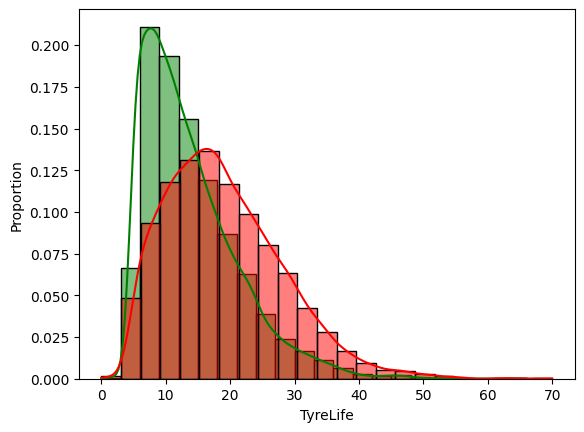

In [11]:
sns.histplot(df[df["target"]>0]["TyreLife"], kde=True, color="green", stat="proportion", binwidth=3)
sns.histplot(df[df["target"]<0]["TyreLife"], kde=True, color="red", stat="proportion", binwidth=3)
plt.show()

In [12]:
for i in range(5,76,5):
    x=df[(df["target"]>0)&(df["TyreLife"]<=i)&(df["TyreLife"]>i-5)]["TyreLife"].count()
    y=df[(df["target"]<0)&(df["TyreLife"]<=i)&(df["TyreLife"]>i-5)]["TyreLife"].count()
    z=df[(df["target"]==0)&(df["TyreLife"]<=i)&(df["TyreLife"]>i-5)]["TyreLife"].count()
    print(f"{i-5} - {i}\n gain:{x/(x+y+z)*100} \n depress:{y/(x+y+z)*100} \n neither:{z/(x+y+z)*100}\n \n")

0 - 5
 gain:42.17787632421779 
 depress:7.563439270756343 
 neither:50.25868440502587
 

5 - 10
 gain:38.27982250065257 
 depress:9.06203776211607 
 neither:52.65813973723136
 

10 - 15
 gain:32.08809057469068 
 depress:13.524100702240482 
 neither:54.387808723068844
 

15 - 20
 gain:26.180529180908973 
 depress:18.31877452842132 
 neither:55.5006962906697
 

20 - 25
 gain:22.328533535430086 
 depress:20.803334596438045 
 neither:56.86813186813187
 

25 - 30
 gain:15.982018291737715 
 depress:23.438226631529997 
 neither:60.57975507673229
 

30 - 35
 gain:15.656420568802067 
 depress:24.274633725940824 
 neither:60.068945705257114
 

35 - 40
 gain:13.202933985330073 
 depress:22.43276283618582 
 neither:64.3643031784841
 

40 - 45
 gain:10.932944606413994 
 depress:22.303206997084548 
 neither:66.76384839650146
 

45 - 50
 gain:16.50485436893204 
 depress:27.831715210355988 
 neither:55.663430420711975
 

50 - 55
 gain:6.666666666666667 
 depress:22.666666666666664 
 neither:70.6666666

after 25 laps the gain distribution becomes less so before 25 laps position gain has more association

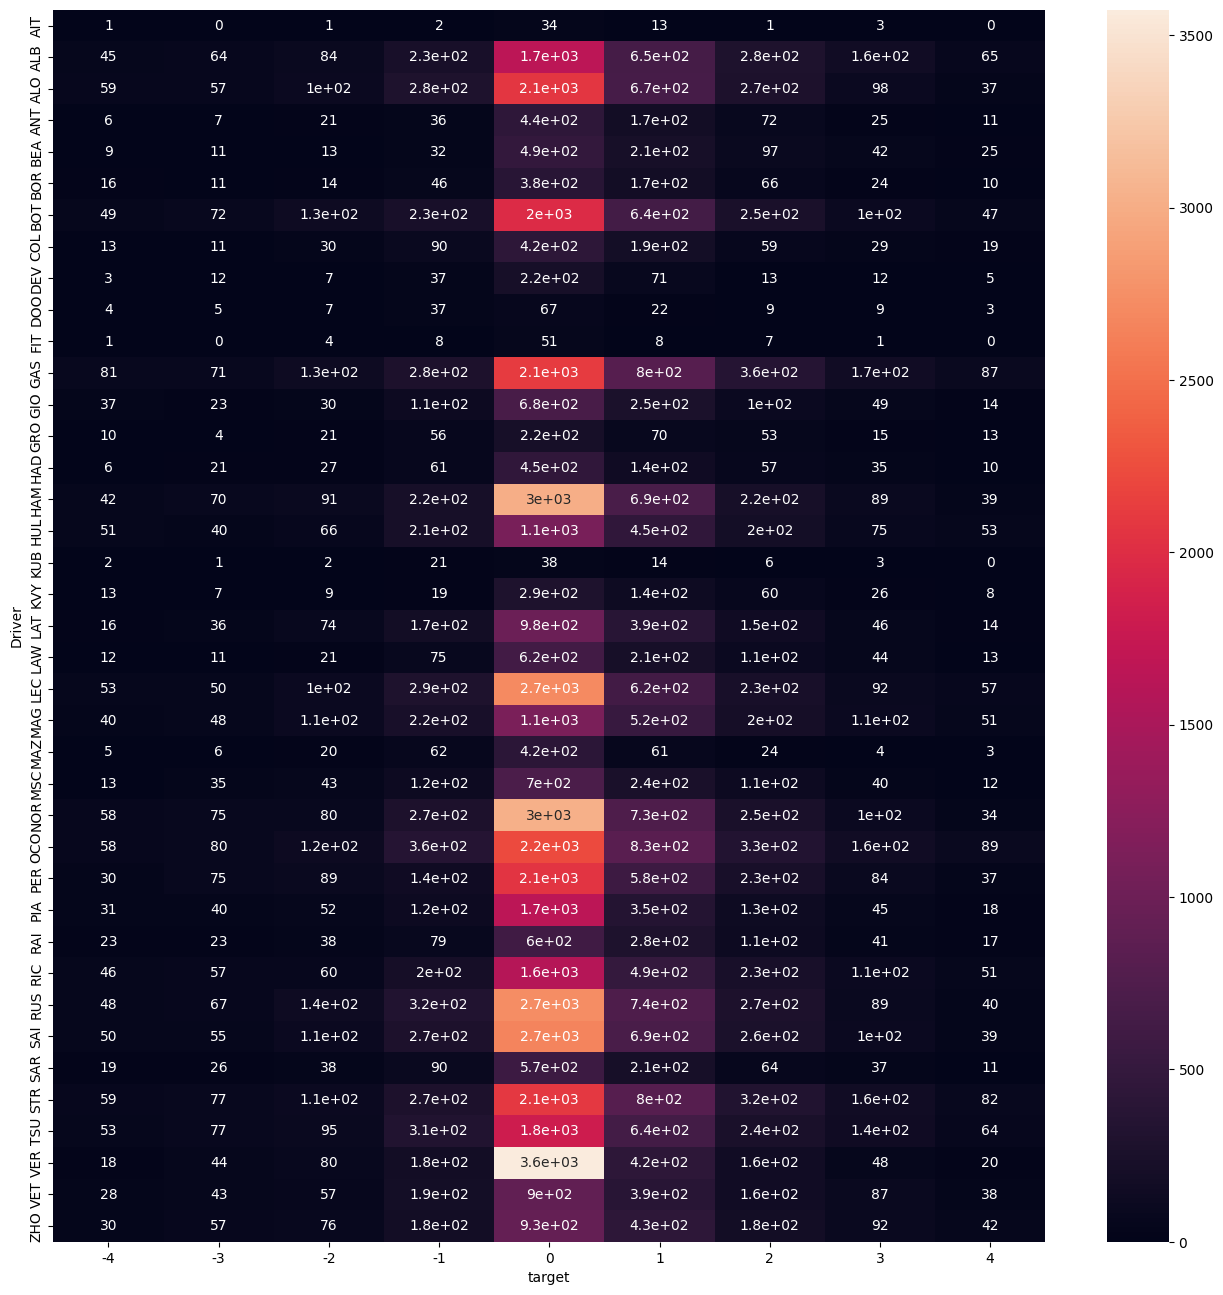

In [13]:
plt.figure(figsize=(16,16))
sns.heatmap(pd.crosstab(df[(df["target"]<5)&(df["target"]>-5)]["Driver"], df[(df["target"]<5)&(df["target"]>-5)]["target"]), annot=True)
plt.show()

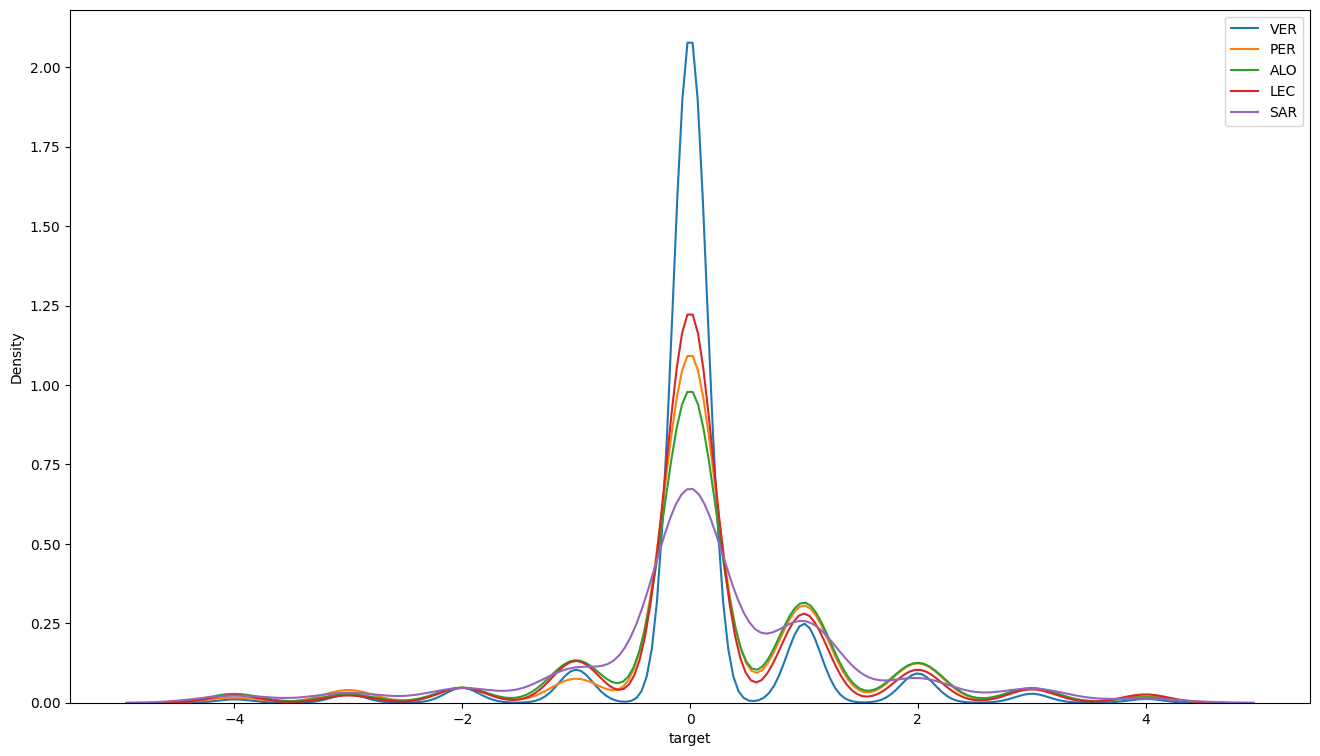

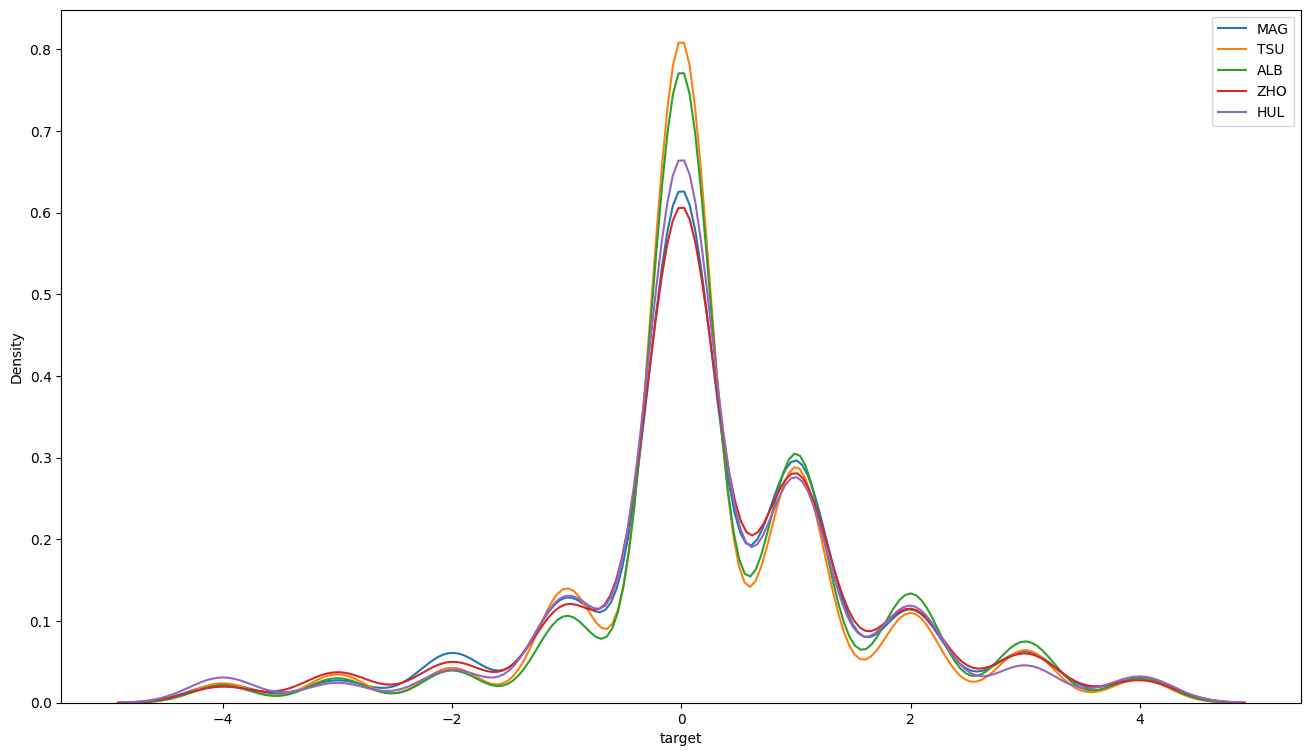

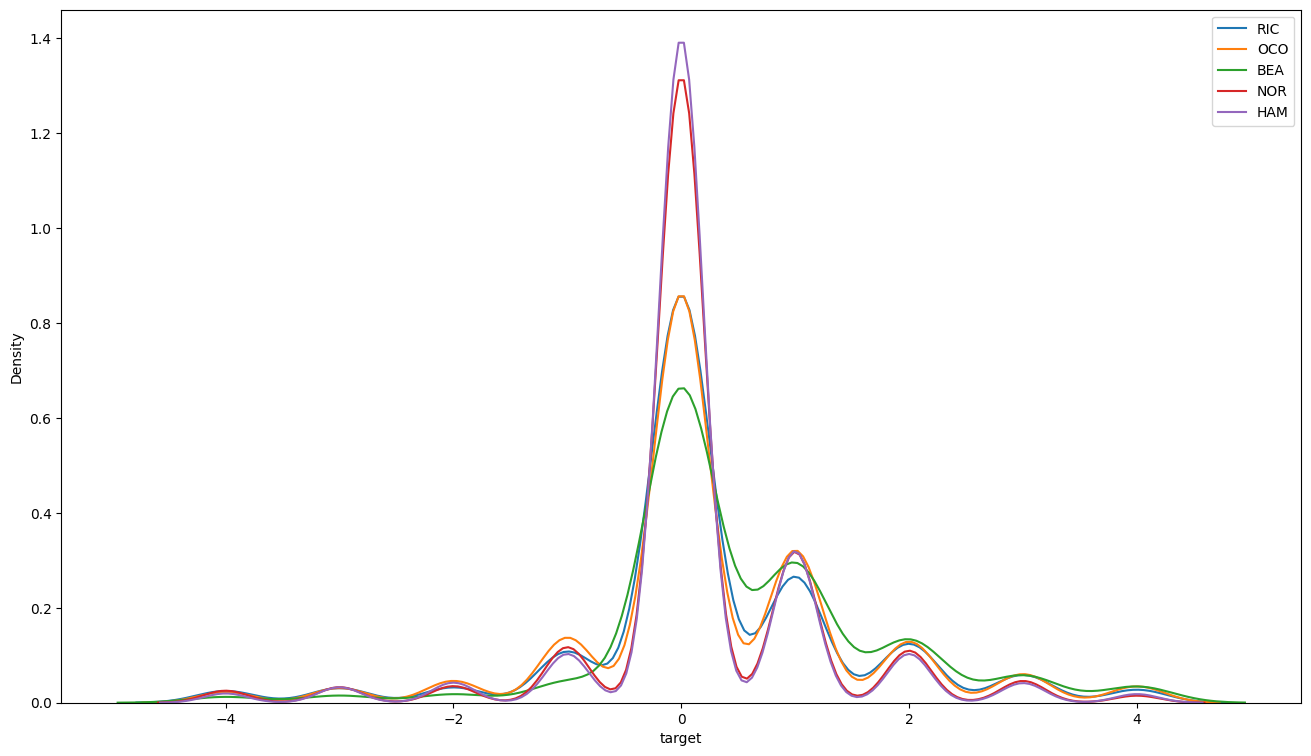

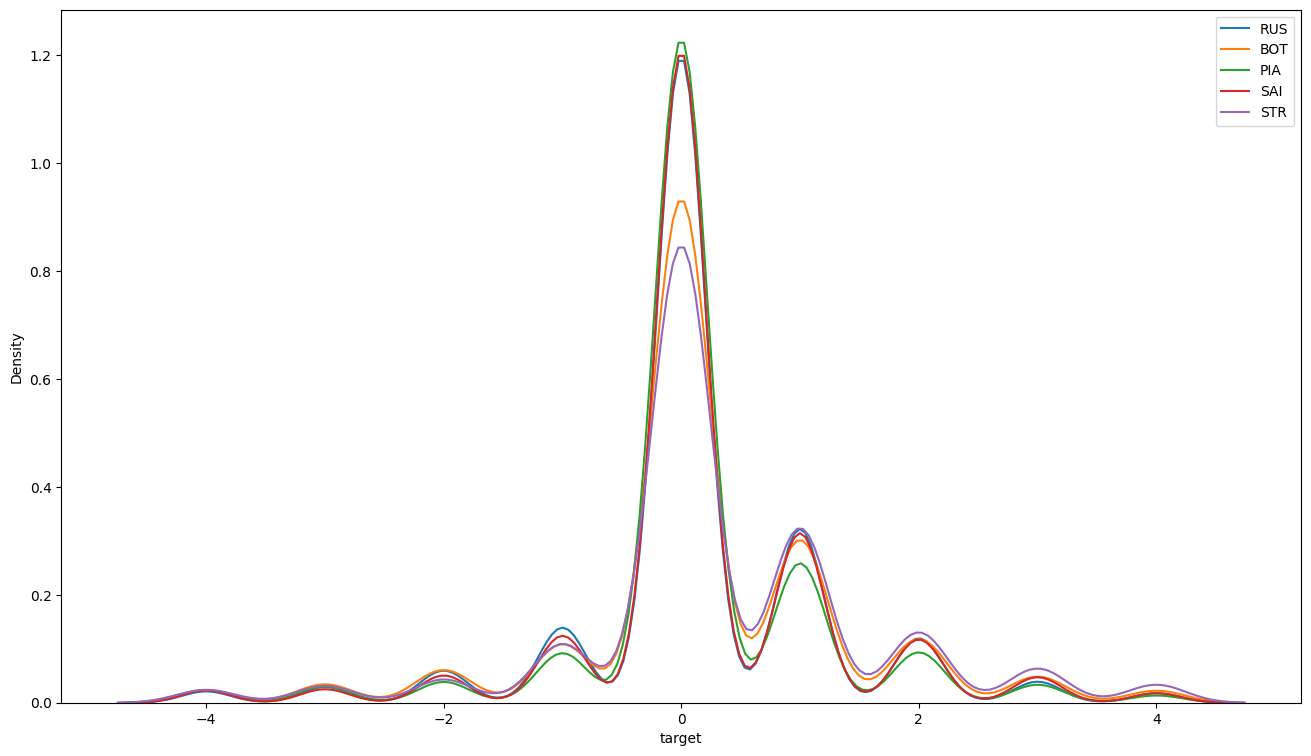

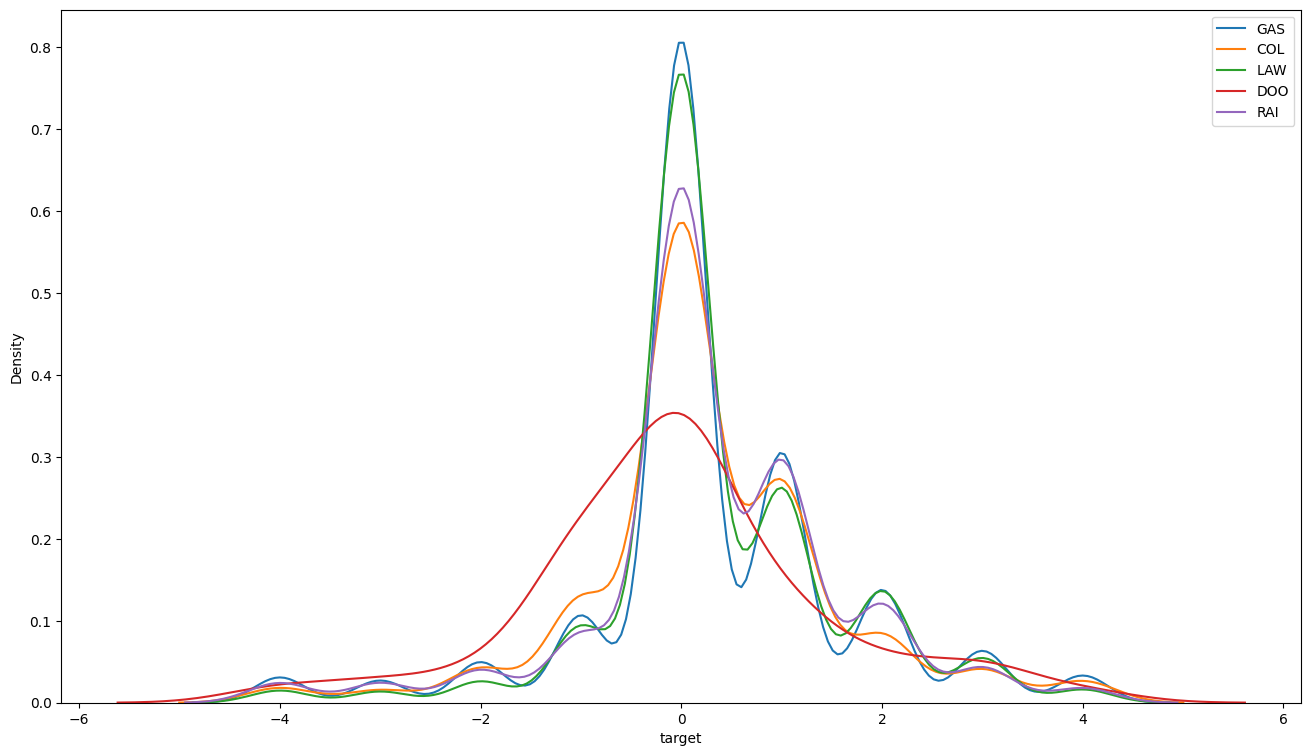

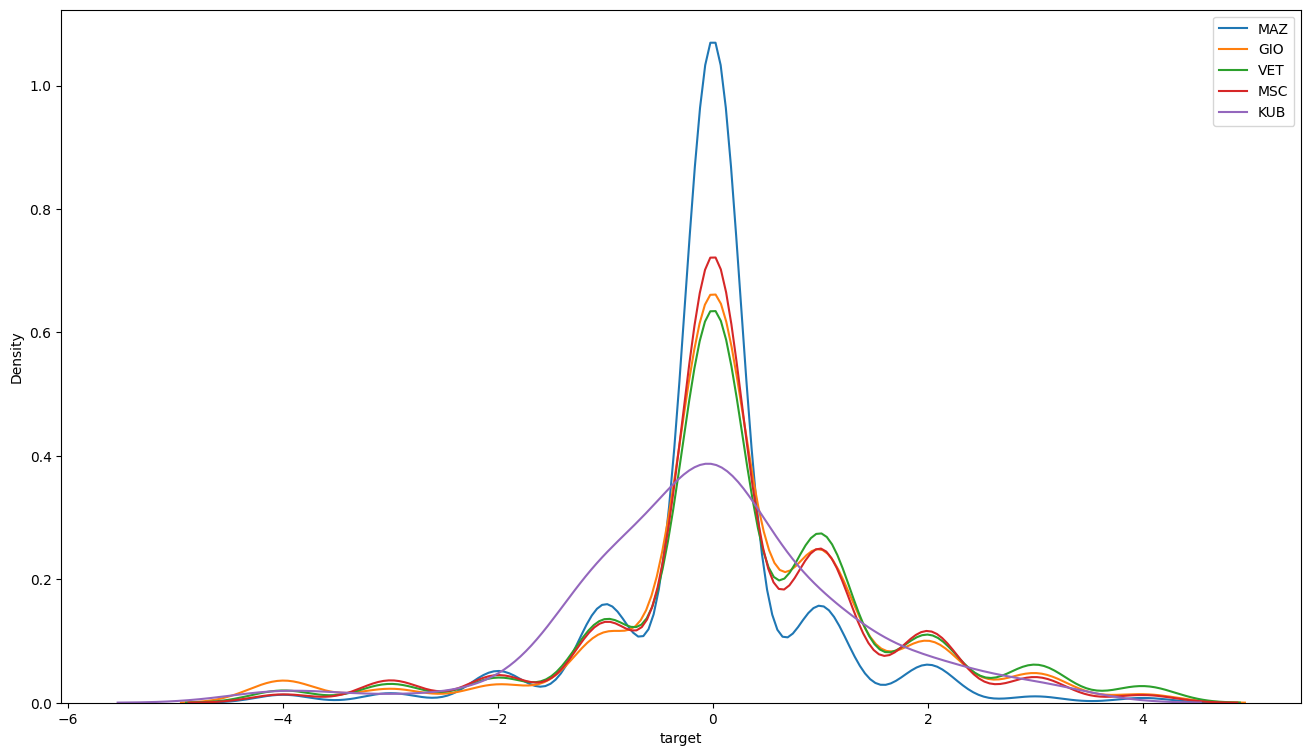

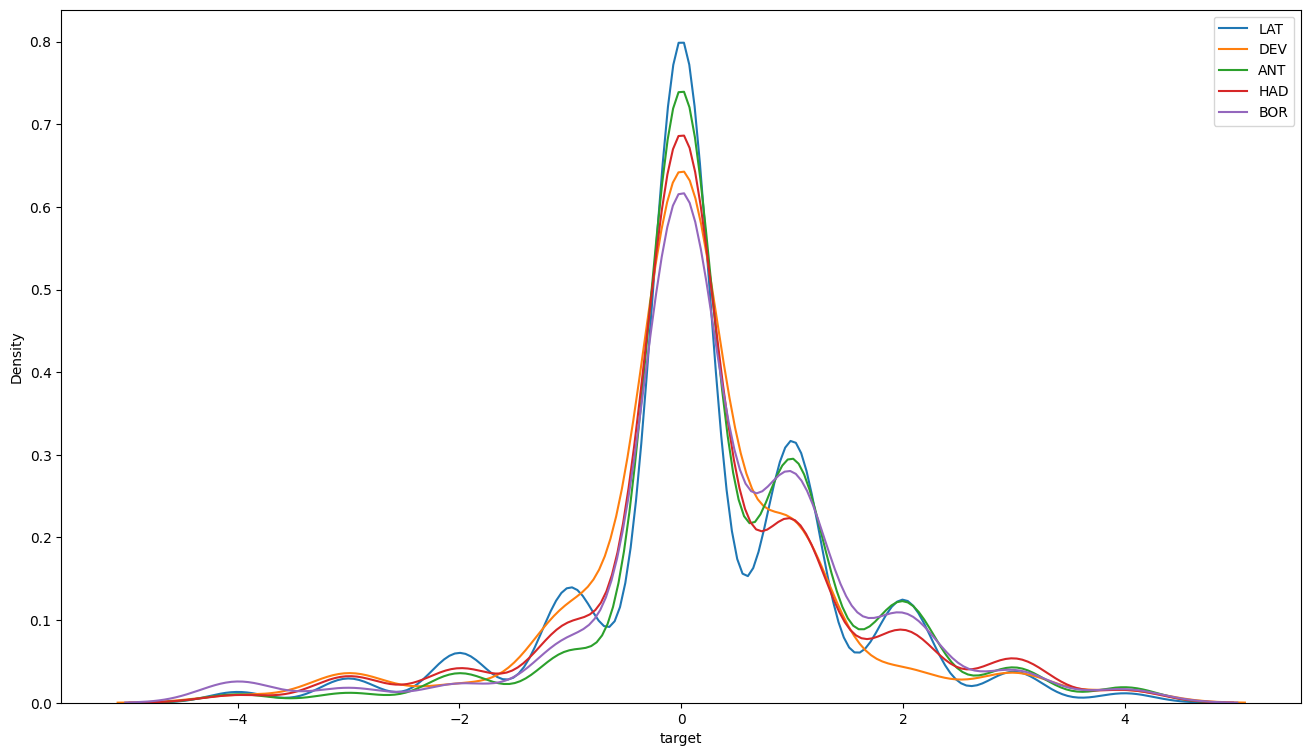

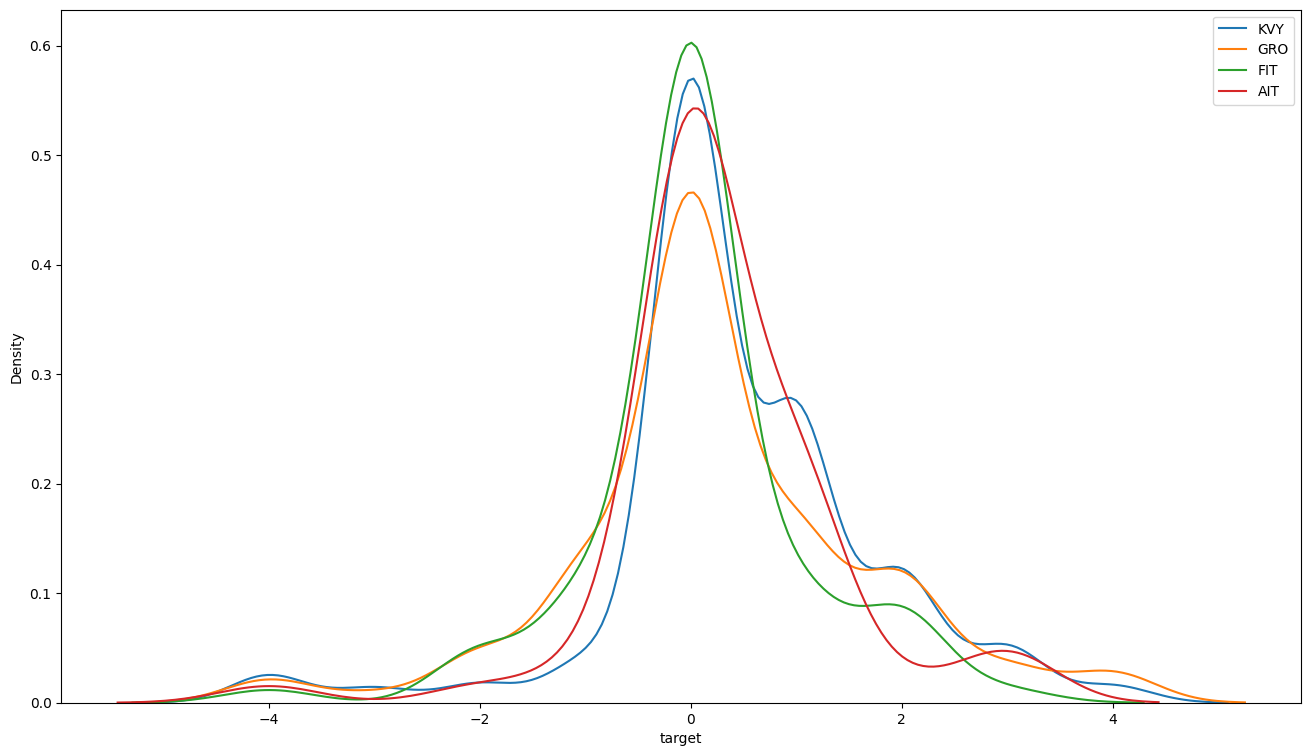

In [14]:
plt.figure(figsize=(16,9))
j=0
for i in df["Driver"].unique():
    j+=1
    sns.kdeplot(df[(df["Driver"]==i)&(df["target"]<5)&(df["target"]>-5)]["target"], label=i, )
    if j%5==0:
        plt.legend()
        plt.show()
        plt.figure(figsize=(16,9))
plt.legend()
plt.show()

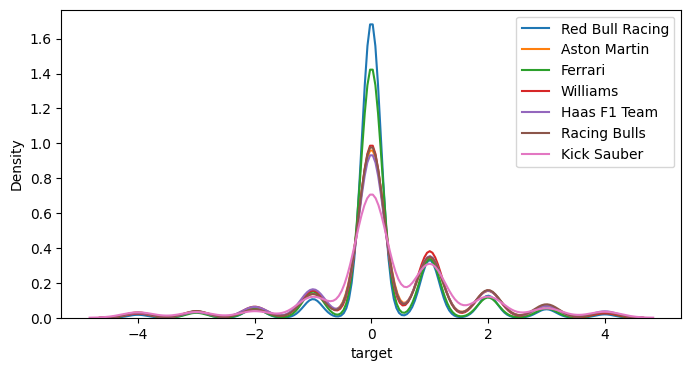

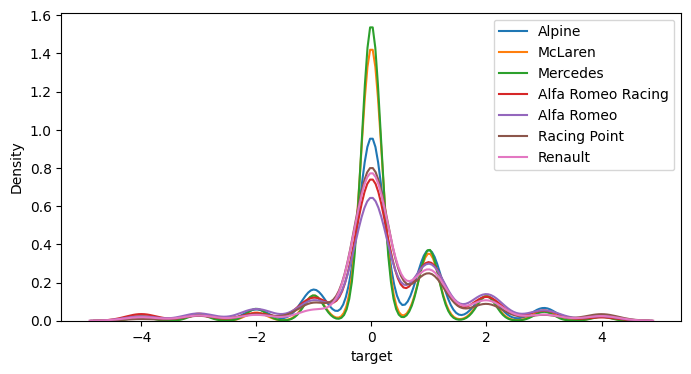

/tmp/ipykernel_6178/3363242761.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


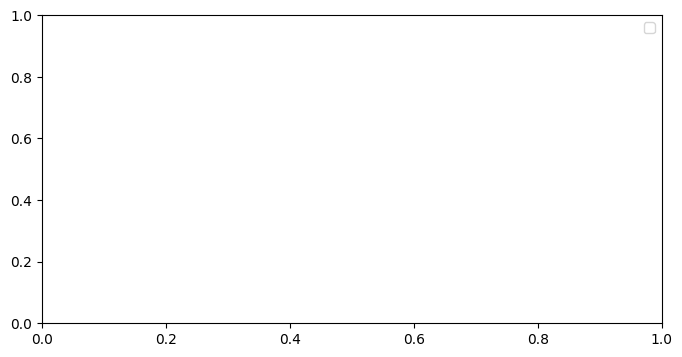

In [15]:

plt.figure(figsize=(8,4))
j=0
for i in df["Team"].unique():
    j+=1
    sns.kdeplot(df[(df["Team"]==i)&(df["target"]<5)&(df["target"]>-5)]["target"], label=i, )
    if j%7==0:
        plt.legend()
        plt.show()
        plt.figure(figsize=(8,4))
plt.legend()
plt.show()

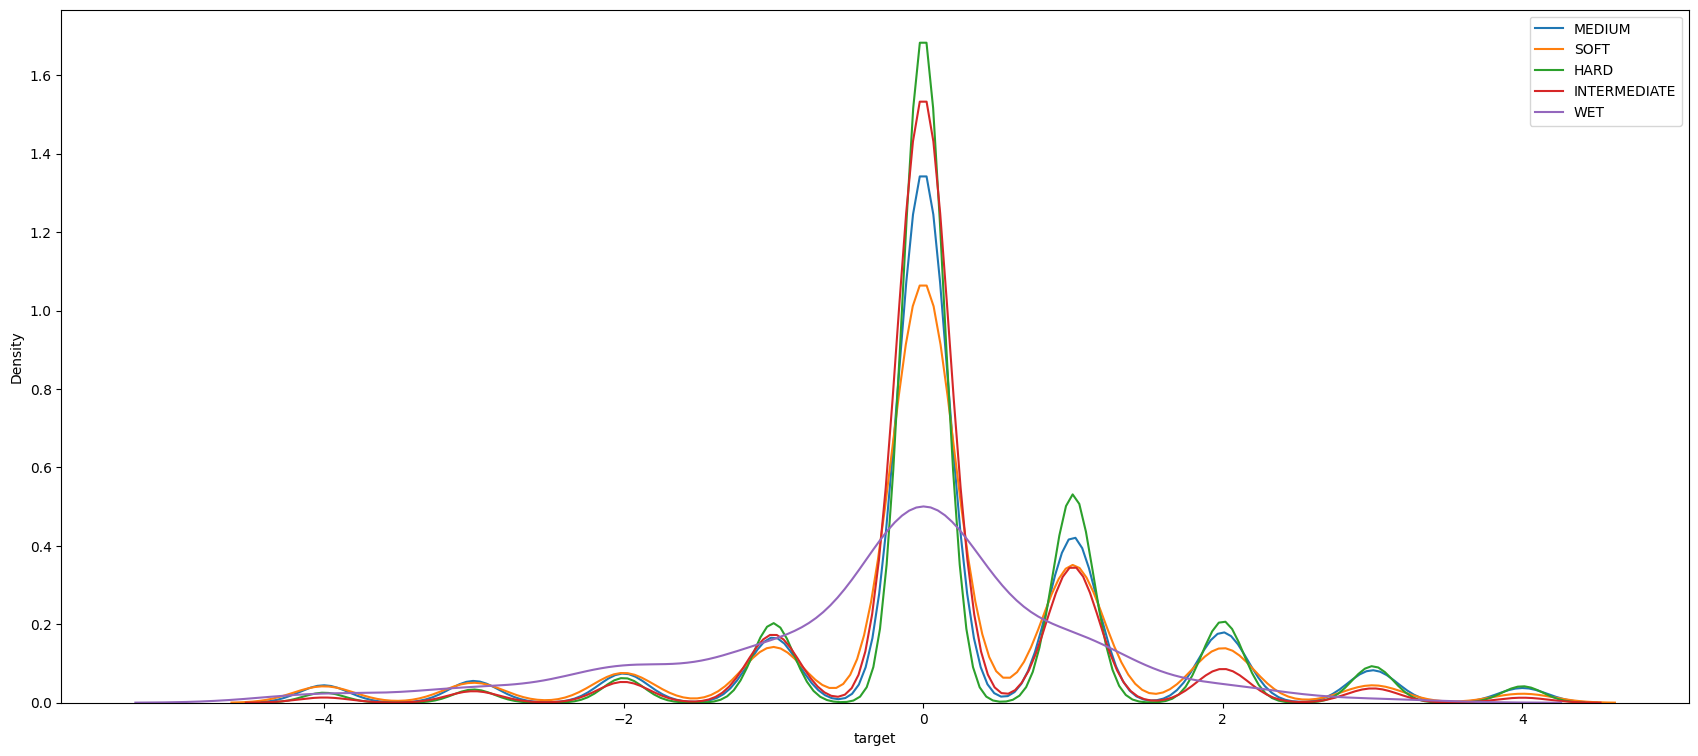

In [16]:

plt.figure(figsize=(21,9))
j=0
for i in df["Compound"].unique():
    j+=1
    sns.kdeplot(df[(df["Compound"]==i)&(df["target"]<5)&(df["target"]>-5)]["target"], label=i, )
    
plt.legend()
plt.show()

In [17]:
df.columns

Index(['Driver', 'Position', 'Team', 'Compound', 'TyreLife', 'LapTime',
       'mean_last_5', 'median_last_5', 'mean_last_3', 'median_last_3',
       'p_minus1_time_delta', 'p_minus2_time_delta', 'p_minus3_time_delta',
       'p_plus1_time_delta', 'p_plus2_time_delta', 'p_plus3_time_delta',
       'p_minus1_mean_LapTime', 'p_minus2_mean_LapTime',
       'p_minus3_mean_LapTime', 'p_minus1_median_LapTime',
       'p_minus2_median_LapTime', 'p_minus3_median_LapTime',
       'p_plus1_mean_LapTime', 'p_plus2_mean_LapTime', 'p_plus3_mean_LapTime',
       'p_plus1_median_LapTime', 'p_plus2_median_LapTime',
       'p_plus3_median_LapTime', 'p_3_minus1_mean_LapTime',
       'p_3_minus2_mean_LapTime', 'p_3_minus3_mean_LapTime',
       'p_3_minus1_median_LapTime', 'p_3_minus2_median_LapTime',
       'p_3_minus3_median_LapTime', 'p_3_plus1_mean_LapTime',
       'p_3_plus2_mean_LapTime', 'p_3_plus3_mean_LapTime',
       'p_3_plus1_median_LapTime', 'p_3_plus2_median_LapTime',
       'p_3_plus3_media

In [18]:
import fastf1
session = fastf1.get_session(2026, 7, 5)

req         WARNING 	DEFAULT CACHE ENABLED! (1.3 GB) /home/archit/.cache/fastf1


In [19]:
session.load(laps=True, telemetry=False, weather=False, messages=False)

core           INFO 	Loading data for Barcelona Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core           INFO 	Finished loading data for 22 drivers: ['44', '63', '1', '3', '81', '6', '10', '30', '41', '43', '5', '55', '31', '11', '16', '12', '87', '23', '14', '27', '77', '18']


In [20]:
race=session.laps

In [21]:
race

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:55:08.537000,NOR,1,0 days 00:01:27.198000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:33.656000,...,True,McLaren,0 days 00:53:41.090000,NaT,1,4.0,None,,False,False
1,0 days 00:56:30.788000,NOR,1,0 days 00:01:22.251000,2.0,1.0,NaT,NaT,0 days 00:00:23.744000,0 days 00:00:33.611000,...,True,McLaren,0 days 00:55:08.537000,NaT,1,4.0,None,,False,True
2,0 days 00:57:53.210000,NOR,1,0 days 00:01:22.422000,3.0,1.0,NaT,NaT,0 days 00:00:23.976000,0 days 00:00:33.500000,...,True,McLaren,0 days 00:56:30.788000,NaT,1,4.0,None,,False,True
3,0 days 00:59:15.983000,NOR,1,0 days 00:01:22.773000,4.0,1.0,NaT,NaT,0 days 00:00:23.999000,0 days 00:00:33.552000,...,True,McLaren,0 days 00:57:53.210000,NaT,1,4.0,None,,False,True
4,0 days 01:00:39.270000,NOR,1,0 days 00:01:23.287000,5.0,1.0,NaT,NaT,0 days 00:00:24.189000,0 days 00:00:33.813000,...,True,McLaren,0 days 00:59:15.983000,NaT,1,4.0,None,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1231,0 days 02:14:22.044000,BEA,87,0 days 00:01:27.738000,56.0,3.0,NaT,NaT,0 days 00:00:26.538000,0 days 00:00:35.203000,...,False,Haas F1 Team,0 days 02:12:54.306000,NaT,1,13.0,None,,False,True
1232,0 days 02:15:46.781000,BEA,87,0 days 00:01:24.737000,57.0,3.0,NaT,NaT,0 days 00:00:24.606000,0 days 00:00:34.204000,...,False,Haas F1 Team,0 days 02:14:22.044000,NaT,1,13.0,None,,False,True
1233,0 days 02:17:11.160000,BEA,87,0 days 00:01:24.379000,58.0,3.0,NaT,NaT,0 days 00:00:24.556000,0 days 00:00:34.091000,...,False,Haas F1 Team,0 days 02:15:46.781000,NaT,1,13.0,None,,False,True
1234,0 days 02:18:35.266000,BEA,87,0 days 00:01:24.106000,59.0,3.0,NaT,NaT,0 days 00:00:24.540000,0 days 00:00:33.913000,...,False,Haas F1 Team,0 days 02:17:11.160000,NaT,1,13.0,None,,False,True


In [22]:
race[(race["Driver"]=="HAM")& (race["PitOutTime"].notna())]

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
781,0 days 01:10:40.483000,HAM,44,0 days 00:01:40.800000,12.0,2.0,0 days 01:09:19.431000,NaT,0 days 00:00:43.608000,0 days 00:00:32.602000,...,True,Ferrari,0 days 01:08:59.683000,NaT,1,7.0,None,,False,False
797,0 days 01:33:02.212000,HAM,44,0 days 00:01:39.857000,28.0,3.0,0 days 01:31:42.187000,NaT,0 days 00:00:43.068000,0 days 00:00:32.294000,...,True,Ferrari,0 days 01:31:22.355000,NaT,1,7.0,None,,False,False
811,0 days 01:52:47.561000,HAM,44,0 days 00:01:41.055000,42.0,4.0,0 days 01:51:26.586000,NaT,0 days 00:00:45.719000,0 days 00:00:31.391000,...,True,Ferrari,0 days 01:51:06.506000,NaT,671,1.0,None,,False,False


In [23]:
pseudo=race[(race["LapNumber"]>18)&(race["LapNumber"]<28)].sort_values(["TyreLife"])

In [24]:
def to_seconds(x):
    return x.total_seconds()

In [25]:
race["LapTime"] = race["LapTime"].apply(to_seconds)

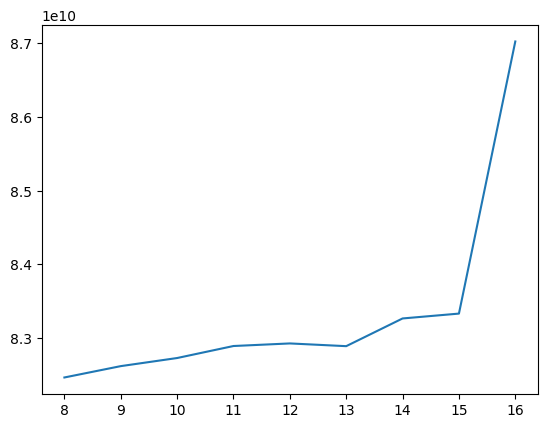

In [26]:
plt.plot(pseudo[pseudo["Driver"]=="HAM"]["TyreLife"], pseudo[pseudo["Driver"]=="HAM"]["LapTime"])
plt.show()

In [27]:
race["TyreLife"].unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30., 31., nan])

In [28]:
race=race[race["LapNumber"]>10].copy()

In [29]:
lapTime=list()
life=list()
for i in range(1,33):
    lapTime.append(race[(race["TyreLife"]==i)&(race["Compound"]=="HARD")]["LapTime"].median())
    life.append(i)
    

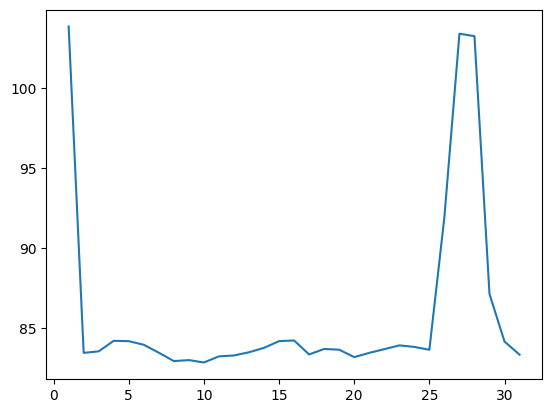

In [30]:
plt.plot(life,lapTime)
plt.show()

In [31]:
lapTime=list()
life=list()
for i in range(1,33):
    lapTime.append(race[(race["TyreLife"]==i)&(race["Compound"]=="MEDIUM")]["LapTime"].median())
    life.append(i)
    

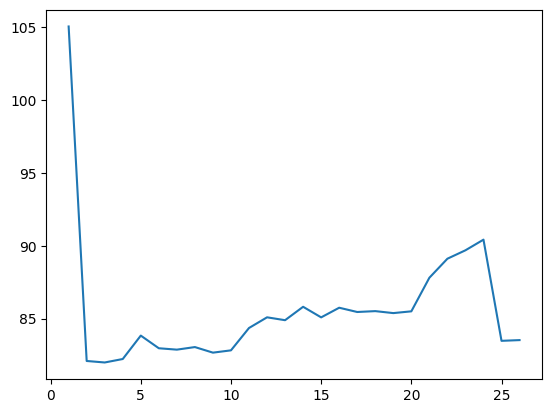

In [32]:
plt.plot(life,lapTime)
plt.show()

In [33]:
lapTime=list()
life=list()
for i in range(1,33):
    lapTime.append(race[(race["TyreLife"]==i)&(race["Compound"]=="SOFT")]["LapTime"].median())
    life.append(i)
    

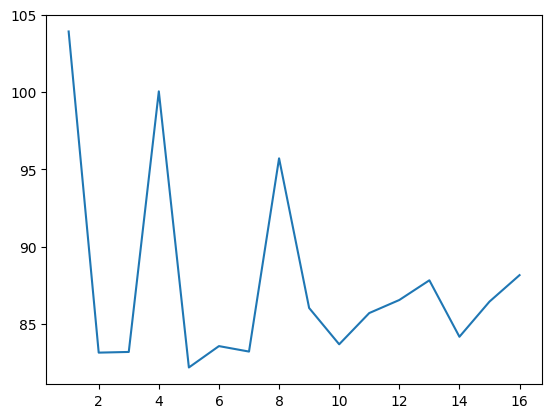

In [34]:
plt.plot(life,lapTime)
plt.show()

In [35]:
lapTime=list()
life=list()
for i in range(1,33):
    lapTime.append(race[(race["TyreLife"]==i)]["LapTime"].median())
    life.append(i)
    

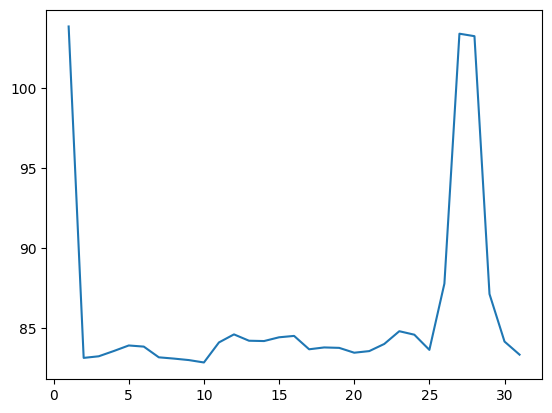

In [36]:
plt.plot(life,lapTime)
plt.show()

data shows the lap time rises as the tyre age rises and the initial laps of the tyre are also bit slower than the pace between 5 to 10 lap tyre life

<Axes: xlabel='TyreLife', ylabel='Count'>

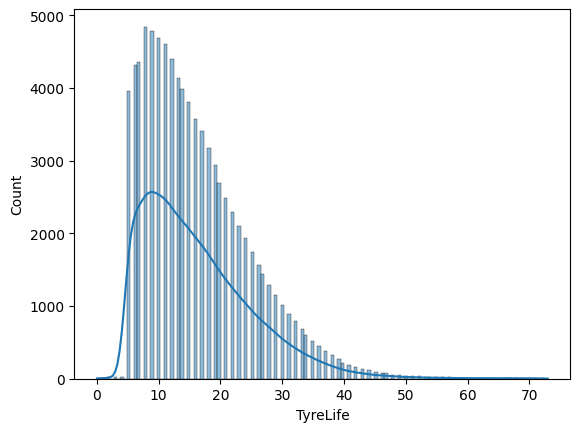

In [37]:
sns.histplot(df["TyreLife"], kde=True)

In [38]:
df["TyreLife"].describe()

count    87277.000000
mean        16.262360
std          8.953957
min          0.000000
25%          9.000000
50%         14.000000
75%         21.000000
max         73.000000
Name: TyreLife, dtype: float64

<Axes: xlabel='TyreLife', ylabel='Proportion'>

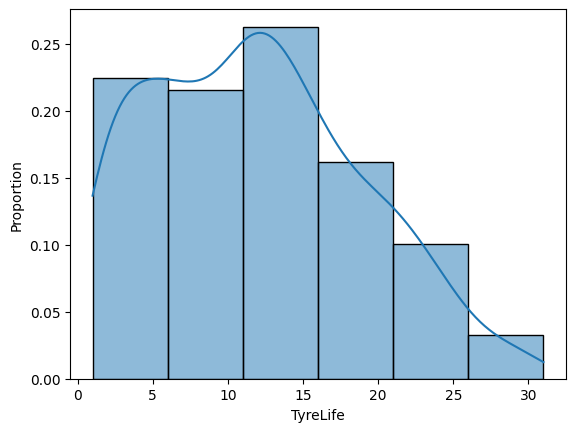

In [46]:
sns.histplot(race["TyreLife"], kde=True, binwidth=5, stat="proportion")

<Axes: xlabel='TyreLife', ylabel='Proportion'>

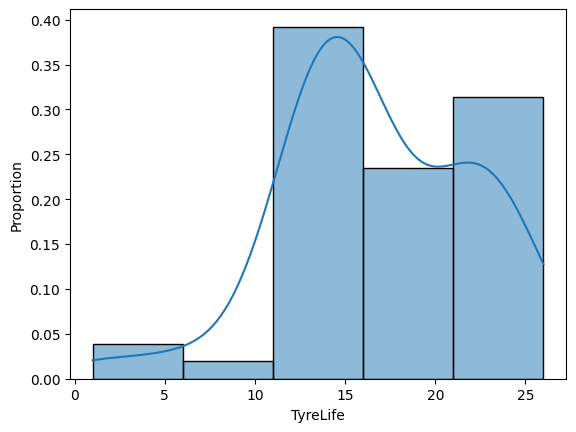

In [ ]:
sns.histplot(race[race["PitInTime"].notna()]["TyreLife"], kde=True, binwidth=5, stat="proportion")

In [41]:
race[race["PitInTime"].notna()]["TyreLife"].describe()

count    51.000000
mean     16.764706
std       5.338870
min       1.000000
25%      13.500000
50%      16.000000
75%      21.500000
max      26.000000
Name: TyreLife, dtype: float64

in this particular race about 40% driver pi in between laps 11-16 lap and combined data also shows the similar story although we didn't have the info about pit phases but the distribution shows similar association in laps of particular tyre life 